Task 3: Correlation between news sentiment and stock movement

Date Alignment


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from scipy import stats

nltk.download('vader_lexicon', quiet=True)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.family'] = 'serif'
print("Environment Ready!")

Environment Ready!


In [6]:
news_df = pd.read_csv("../data/raw_analyst_ratings.csv")

news_df.head()


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [7]:
stock_df = pd.read_csv("../data/AAPL.csv")
stock_df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [8]:
news_df['date'] = pd.to_datetime(
    news_df['date'],
    format='mixed',
    utc=True,
    errors='coerce'
)


In [9]:
news_df['date_only'] = news_df['date'].dt.date

In [ ]:

stock_df['Date'] = pd.to_datetime(stock_df['Date'])

In [20]:
news_df['date_only'] = news_df['date'].dt.date

Calculate Daily Returns and preview

In [22]:
stock_df['daily_return'] = stock_df['Close'].pct_change() * 100

stock_df[['Date', 'Close', 'daily_return']].head()

,Date,Close,daily_return
0,2009-01-02,2.721686,NaN
1,2009-01-05,2.836553,4.220416
2,2009-01-06,2.789767,-1.649399
3,2009-01-07,2.729484,-2.160860
4,2009-01-08,2.780169,1.856959


Initialize Sentiment Analyzer and Compute Headline Sentiment

In [24]:
sia = SentimentIntensityAnalyzer()

news_df['sentiment_score'] = news_df['headline'].astype(str).apply(
    lambda x: sia.polarity_scores(x)['compound']
)

In [25]:
news_df[['headline', 'sentiment_score']].head()

,headline,sentiment_score
0,Stocks That Hit 52-Week Highs On Friday,0.000
1,Stocks That Hit 52-Week Highs On Wednesday,0.000
2,71 Biggest Movers From Friday,0.000
3,46 Stocks Moving In Friday's Mid-Day Session,0.000
4,B of A Securities Maintains Neutral on Agilent...,0.296


Aggregate Daily Sentiment

In [26]:
daily_sentiment = news_df.groupby('date_only')['sentiment_score'].mean().reset_index()

daily_sentiment.head()

,date_only,sentiment_score
0,2009-02-16,0.22630
1,2009-04-27,0.00000
2,2009-04-29,0.00000
3,2009-05-22,0.00000
4,2009-05-27,0.75105


In [29]:
stock_df['Date'] = pd.to_datetime(stock_df['Date'])

stock_df['date_only'] = stock_df['Date'].dt.date

Merge Sentiment and Stock Data

In [30]:
merged_df = pd.merge(
    stock_df,
    daily_sentiment,
    on='date_only',
    how='inner'
)

merged_df.head()

,Date,Close,High,Low,Open,Volume,daily_return,date_only,sentiment_score
0,2009-04-27,3.740782,3.748880,3.678701,3.685899,480690000,0.669876,2009-04-27,0.00000
1,2009-04-29,3.753081,3.804365,3.713793,3.744384,458110800,1.000849,2009-04-29,0.00000
2,2009-05-22,3.673902,3.724287,3.651409,3.720388,297998400,-1.352902,2009-05-22,0.00000
3,2009-05-27,3.990310,4.048192,3.926129,3.952221,646422000,1.735764,2009-05-27,0.75105
4,2009-05-29,4.073082,4.075781,4.014300,4.060486,456534400,0.547854,2009-05-29,0.00000


In [ ]:
Compute Pearson Correlation

In [31]:
correlation = merged_df['sentiment_score'].corr(
    merged_df['daily_return']
)

print("Pearson Correlation:", correlation)

Pearson Correlation: 0.14342524634301196


Scatter Plot

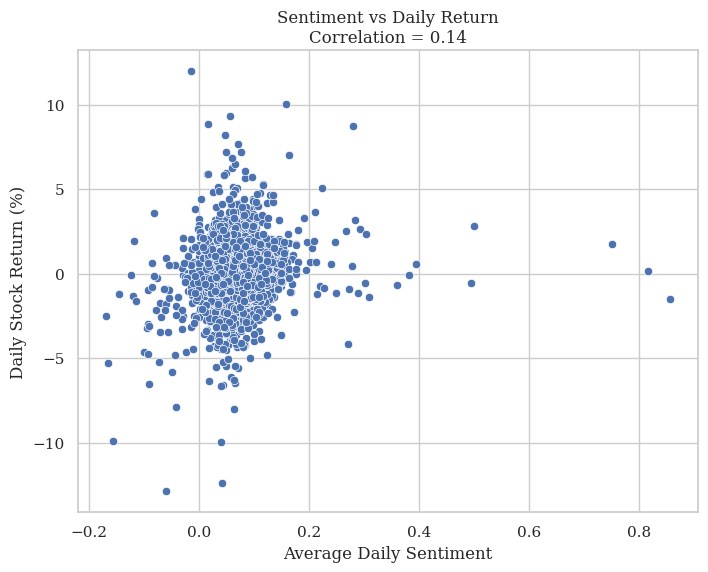

In [32]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=merged_df,
    x='sentiment_score',
    y='daily_return'
)

plt.title(f"Sentiment vs Daily Return\nCorrelation = {correlation:.2f}")

plt.xlabel("Average Daily Sentiment")

plt.ylabel("Daily Stock Return (%)")

plt.show()

Classify Sentiment

In [33]:
def classify_sentiment(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'
    


In [35]:
merged_df['sentiment_category'] = merged_df['sentiment_score'].apply(
    classify_sentiment
)

merged_df.head()

,Date,Close,High,Low,Open,Volume,daily_return,date_only,sentiment_score,sentiment_category
0,2009-04-27,3.740782,3.748880,3.678701,3.685899,480690000,0.669876,2009-04-27,0.00000,Neutral
1,2009-04-29,3.753081,3.804365,3.713793,3.744384,458110800,1.000849,2009-04-29,0.00000,Neutral
2,2009-05-22,3.673902,3.724287,3.651409,3.720388,297998400,-1.352902,2009-05-22,0.00000,Neutral
3,2009-05-27,3.990310,4.048192,3.926129,3.952221,646422000,1.735764,2009-05-27,0.75105,Positive
4,2009-05-29,4.073082,4.075781,4.014300,4.060486,456534400,0.547854,2009-05-29,0.00000,Neutral


Average Return by Sentiment Category

In [36]:
category_returns = merged_df.groupby(
    'sentiment_category'
)['daily_return'].mean()

category_returns

sentiment_category
Negative   -2.313083
Neutral    -0.099869
Positive    0.247996
Name: daily_return, dtype: float64

Bar Chart

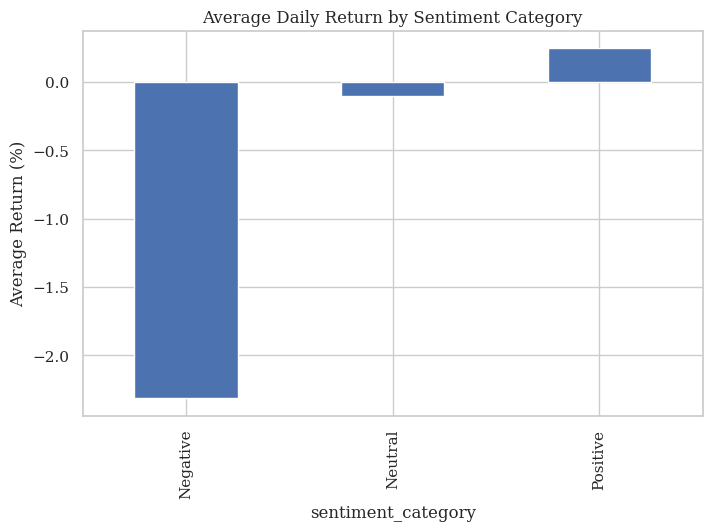

In [37]:
category_returns.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Average Daily Return by Sentiment Category")

plt.ylabel("Average Return (%)")

plt.show()

Handle Weekend/Holiday News

In [39]:
news_df['date_only'] = pd.to_datetime(news_df['date_only'])

news_df['date_only'] = news_df['date_only'].apply(
    lambda x: x + pd.Timedelta(days=2) if x.weekday() == 5
    else x + pd.Timedelta(days=1) if x.weekday() == 6
    else x
)
news_df.head()

,Unnamed: 0,headline,url,publisher,date,stock,date_only,sentiment_score
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54+00:00,A,2020-06-05,0.000
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20+00:00,A,2020-06-03,0.000
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07+00:00,A,2020-05-26,0.000
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06+00:00,A,2020-05-22,0.000
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59+00:00,A,2020-05-22,0.296


The correlation between news sentiment and daily stock returns was weakly positive. 
This suggests that positive financial news headlines may have a slight association 
with increases in stock prices, although the relationship is not strong enough to 
imply causation.

Several limitations affect the analysis. Financial markets are influenced by many 
external factors such as macroeconomic events, earnings reports, and investor 
behavior. Additionally, sentiment derived only from headlines may not fully capture 
the context of the complete articles.